In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

In [11]:
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

In [12]:
def evaluate_model(name, y_true, y_pred):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
    print("Confusion Matrix:\n", cm)
    print()
    return {"model": name, "precision": precision, "recall": recall, "f1": f1}

In [13]:
results = []

In [14]:
results.append({"model": "LogReg (baseline)", "precision": 0.8495, "recall": 0.5563, "f1": 0.6723})
results.append({"model": "Random Forest (baseline)", "precision": 0.9569, "recall": 0.7817, "f1": 0.8605})

In [15]:
log_reg_cw = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg_cw.fit(X_train, y_train)
y_pred = log_reg_cw.predict(X_test)
results.append(evaluate_model("LogReg (class_weight=balanced)", y_test, y_pred))

--- LogReg (class_weight=balanced) ---
Precision: 0.0529 | Recall: 0.8873 | F1: 0.0998
Confusion Matrix:
 [[82718  2258]
 [   16   126]]



In [16]:
rf_cw = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1)
rf_cw.fit(X_train, y_train)
y_pred = rf_cw.predict(X_test)
results.append(evaluate_model("Random Forest (class_weight=balanced)", y_test, y_pred))

--- Random Forest (class_weight=balanced) ---
Precision: 0.9619 | Recall: 0.7113 | F1: 0.8178
Confusion Matrix:
 [[84972     4]
 [   41   101]]



In [17]:
comparison_df = pd.DataFrame(results)
comparison_df

,model,precision,recall,f1
0,LogReg (baseline),0.849500,0.556300,0.672300
1,Random Forest (baseline),0.956900,0.781700,0.860500
2,LogReg (class_weight=balanced),0.052852,0.887324,0.099762
3,Random Forest (class_weight=balanced),0.961905,0.711268,0.817814


In [19]:
joblib.dump(log_reg_cw, "logreg_class_weighted.joblib")
joblib.dump(rf_cw, "rf_class_weighted.joblib")

['rf_class_weighted.joblib']

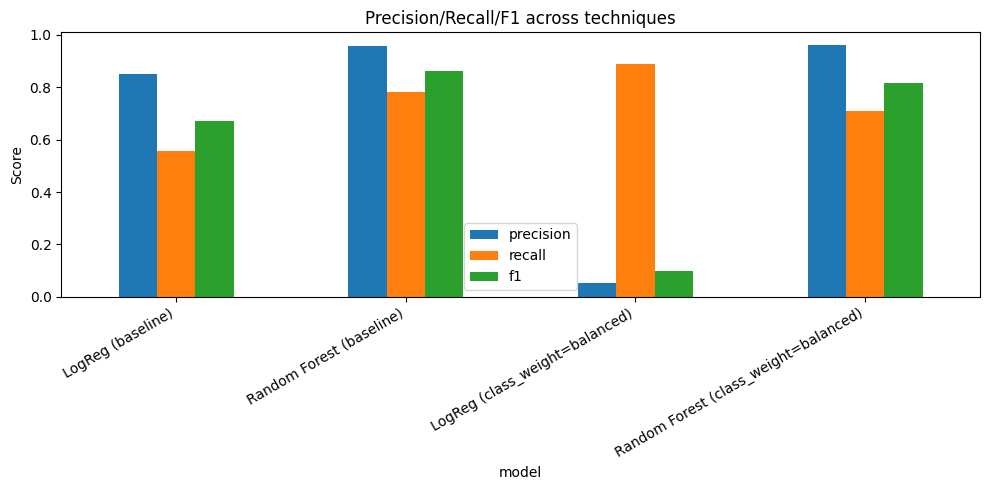

In [20]:
comparison_df.set_index("model")[["precision", "recall", "f1"]].plot(
    kind="bar", figsize=(10, 5)
)
plt.title("Precision/Recall/F1 across techniques")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()